In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [8]:
train = pd.read_csv("digit-recognizer/train.csv")
test = pd.read_csv("digit-recognizer/test.csv")
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
train = np.array(train)
m,n = train.shape
np.random.shuffle(train)
train_dev = train[0:1000].T
Y_dev = train_dev[0]
X_dev = train_dev[1:n]
X_dev = X_dev / 255.
data_train = train[1000:m].T
Y_train = data_train[0]
X_train = data_train[1:n]
X_train = X_train / 255.
_,m_train = X_train.shape

In [10]:
X_train[:,0].shape

(784,)

In [11]:
def init_params():
    w1 = np.random.rand(10, 784) - 0.5
    b1 = np.random.rand(10, 1) - 0.5
    w2 = np.random.rand(10, 10) - 0.5
    b2 = np.random.rand(10, 1) - 0.5
    return w1,b1,w2,b2

def ReLU(Z):
    return np.maximum(Z,0) 
def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
def forward_prop(w1,b1,w2,b2, X):
    z1 = w1.dot(X) + b1
    A1 = ReLU(z1)
    z2 = w2.dot(A1) + b2
    A2 = softmax(z2)
    return z1, A1, z2, A2

def One_hot(Y):
    one_hot_y = np.zeros((Y.size, Y.max()+1))
    one_hot_y[np.arange(Y.size), Y] = 1
    one_hot_y = one_hot_y.T
    return one_hot_y

def deriv_ReLU(Z):
    return Z > 0

def back_prop(z1, A1, z2, A2, w2, X, Y):
    m = Y.size
    one_hot_y = One_hot(Y)
    dz2 = A2 - one_hot_y
    dw2 = (dz2.dot(A1.T))/m 
    db2 = np.sum(dz2)/m
    dz1 = w2.T.dot(dz2) * deriv_ReLU(z1)
    dw1 = (dz1.dot(X.T))/m 
    db1 = np.sum(dz1)/m
    return dw1, db1, dw2, db2

def update_params(w1, b1, w2, b2, dw1,db1, dw2,db2, alpha):
    w1 = w1 - alpha*dw1
    b1 = b1 - alpha*db1
    w2 = w2 - alpha*dw2
    b2 = b2 - alpha*db2
    return w1,b1,w2,b2

In [12]:
def get_predictions(A2):
    return np.argmax(A2, 0)
def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) /Y.size

def gradient_descent(X,Y, alpha, iterations):
    w1, b1, w2, b2 = init_params()
    for i in range(iterations):
        z1, A1, z2, A2 = forward_prop(w1,b1,w2,b2, X)
        dw1, db1, dw2, db2 = back_prop(z1, A1, z2, A2, w2, X, Y)
        w1, b1, w2, b2 = update_params(w1, b1, w2, b2, dw1,db1, dw2,db2, alpha)
        if i % 10 == 0:
            print("Iterations:", i)
            print("Accuracy:", get_accuracy(get_predictions(A2), Y))
    return w1, b1, w2, b2 


In [13]:
w1, b1, w2, b2 = gradient_descent(X_train, Y_train, 0.1, 500)

Iterations: 0
[5 5 5 ... 2 5 5] [2 5 0 ... 2 3 3]
Accuracy: 0.07224390243902439
Iterations: 10
[3 3 5 ... 2 5 5] [2 5 0 ... 2 3 3]
Accuracy: 0.178
Iterations: 20
[3 3 0 ... 9 3 3] [2 5 0 ... 2 3 3]
Accuracy: 0.28217073170731705
Iterations: 30
[3 3 0 ... 2 3 3] [2 5 0 ... 2 3 3]
Accuracy: 0.3545121951219512
Iterations: 40
[3 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.422
Iterations: 50
[3 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.48341463414634145
Iterations: 60
[3 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.5301707317073171
Iterations: 70
[3 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.569
Iterations: 80
[8 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.605609756097561
Iterations: 90
[8 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.6272439024390244
Iterations: 100
[8 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.6435609756097561
Iterations: 110
[8 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.6587073170731708
Iterations: 120
[8 3 0 ... 6 3 8] [2 5 0 ... 2 3 3]
Accuracy: 0.670048780487

In [16]:
def make_predictions(X, w1, b1, w2, b2):
    _, _, _, A2 = forward_prop(w1, b1, w2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, w1, b1, w2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], w1, b1, w2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [2]
Label:  2


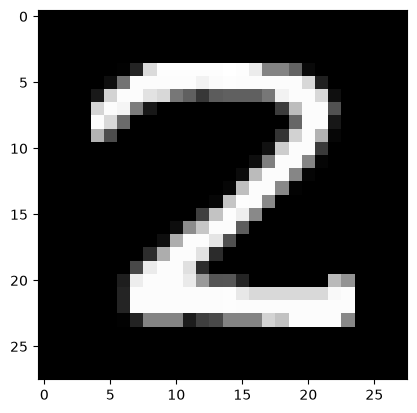

Prediction:  [5]
Label:  5


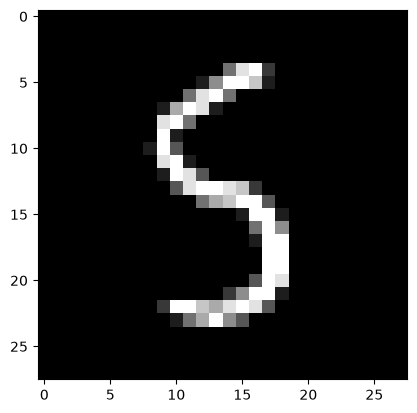

Prediction:  [0]
Label:  0


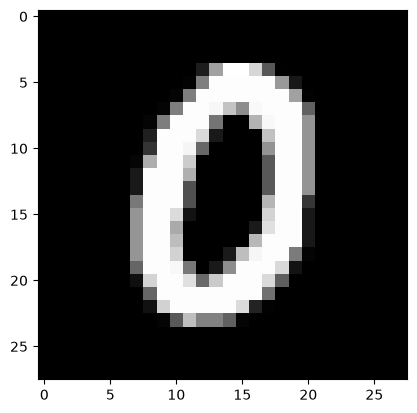

Prediction:  [2]
Label:  1


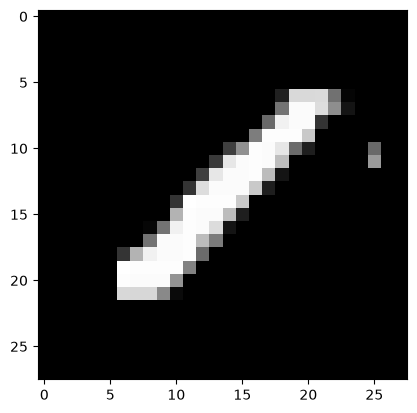

In [17]:
test_prediction(0, w1, b1, w2, b2)
test_prediction(1, w1, b1, w2, b2)
test_prediction(2, w1, b1, w2, b2)
test_prediction(3, w1, b1, w2, b2)

In [19]:
dev_predictions = make_predictions(X_dev, w1, b1, w2, b2)
get_accuracy(dev_predictions, Y_dev)

[5 1 2 1 2 7 1 1 0 2 1 3 4 8 5 0 6 9 8 0 1 4 4 5 8 0 6 9 4 6 0 8 0 9 9 2 3
 8 9 4 6 1 6 9 8 9 9 2 9 2 2 3 4 5 3 8 8 5 1 9 2 5 8 7 6 0 2 0 6 2 6 7 6 3
 7 1 3 2 4 4 0 6 4 5 9 6 4 0 2 5 5 7 8 4 0 4 7 4 6 3 3 3 3 6 3 5 8 3 7 0 6
 3 4 3 4 1 1 1 6 3 0 4 2 7 6 9 1 1 3 5 7 7 8 8 1 8 9 6 8 0 8 7 6 6 9 0 2 5
 6 4 1 6 1 0 9 7 3 5 9 4 1 7 0 1 9 1 8 8 5 0 6 1 5 2 4 5 7 7 4 5 2 3 6 8 0
 6 9 2 3 7 8 1 6 7 6 3 8 3 4 1 4 1 3 6 4 0 6 8 3 1 0 3 4 2 7 9 2 5 7 9 8 6
 3 1 1 9 1 4 8 5 7 6 9 3 9 6 7 1 2 3 3 2 7 9 0 1 8 5 5 4 0 6 6 4 9 5 2 1 2
 1 2 6 6 8 7 7 8 3 0 5 9 7 0 5 0 3 9 3 7 0 1 5 6 7 0 2 2 8 1 0 9 8 3 2 1 8
 1 6 3 6 8 1 1 2 2 9 7 7 6 2 1 1 7 4 7 0 2 9 1 0 8 3 7 8 2 8 1 1 1 9 0 7 3
 6 7 6 1 6 6 3 1 2 1 5 8 9 5 4 9 7 5 6 0 4 0 2 9 6 2 5 8 0 7 8 5 0 4 8 2 3
 6 4 6 7 0 9 3 6 5 3 9 3 1 2 8 3 4 4 3 8 3 0 8 2 8 0 4 1 6 3 5 2 6 1 6 9 1
 8 0 0 7 8 2 5 0 5 8 6 3 3 6 3 9 1 6 4 8 9 4 8 8 1 4 6 2 9 7 1 5 3 7 3 2 0
 1 5 9 4 4 8 0 7 3 9 4 6 8 4 6 6 2 0 8 6 5 9 7 2 5 1 8 4 3 6 9 4 8 4 8 8 4
 3 9 8 0 7 9 3 1 8 8 6 7 

np.float64(0.826)

82.6 % accuracy, could be involved but good for this dry run